# ============================================================
# PART-2 (Per Gene/Target): Data Curation + EDA (Publication)
# Google Colab-ready | Outputs: curated CSVs + TIFF figures
# ============================================================

Final__PART-2 (Per Gene/Target): Data Curation + EDA (Publication)
Google Colab-ready | Outputs: curated CSVs + TIFF figures

✅ Corrected & publication-safer version with:
1) MW vs LogP plot axes fixed (fig, ax = plt.subplots)
2) Boxplot significance uses Mann–Whitney (not t-test)
3) Mann–Whitney effect size fixed (rank-biserial correlation)
4) Strict unit filtering: nM only
5) Save TIFF only (no PNG/PDF)
6) Show all figures in Colab output (plt.show())
"""

In [1]:
# @title  1) Install packages
# ==========================================================
!pip -q install chembl_webresource_client rdkit pandas numpy scipy matplotlib seaborn tqdm

import os
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import mannwhitneyu

import matplotlib.pyplot as plt
import seaborn as sns

from rdkit import Chem
from rdkit.Chem import Descriptors, Lipinski

from chembl_webresource_client.new_client import new_client
from tqdm import tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.1/37.1 MB 43.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.3 MB/s eta 0:00:00


In [2]:
# @title  2) Global plotting settings (publication quality)
# ==========================================================
sns.set_context("paper", font_scale=1.3)
sns.set_style("white")

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "font.family": "DejaVu Sans",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 14,
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "axes.linewidth": 1.2,
    "xtick.major.width": 1.2,
    "ytick.major.width": 1.2,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "legend.frameon": True,
    "legend.edgecolor": "black",
    "legend.fontsize": 10,
    "figure.autolayout": True,
})

def save_tiff(fig, filename_base, dpi=600):
    """Save publication-quality TIFF only (LZW compression when available)."""
    os.makedirs("PART2_OUTPUTS", exist_ok=True)
    path = os.path.join("PART2_OUTPUTS", f"{filename_base}.tiff")
    try:
        fig.savefig(path, format="tiff", dpi=dpi, bbox_inches="tight",
                    pil_kwargs={"compression": "tiff_lzw"})
    except Exception:
        fig.savefig(path, format="tiff", dpi=dpi, bbox_inches="tight")
        print("⚠️ LZW compression not available, saved without compression")
    print(f"✅ Saved: {path}")
    return path

In [3]:
# @title  3) User inputs: SET TARGET_CHEMBL_ID PER GENE
# ==========================================================
TARGET_CHEMBL_ID = "CHEMBL1250348"   # <-- change for each gene (target_chembl_id)
OUTPUT_PREFIX    = "MYC"       # <-- change for each gene (e.g., MYC, STAT3...)

# Activity thresholds (IC50 in nM)
IC50_ACTIVE_NM   = 1000    # ≤ 1 µM
IC50_INACTIVE_NM = 10000   # ≥ 10 µM

# Optional cap to reduce extreme outliers (100 µM = 100,000 nM)
IC50_CAP_NM      = 1e5

print(f"Target: {TARGET_CHEMBL_ID}")
print(f"Output prefix: {OUTPUT_PREFIX}")
print(f"Activity thresholds: Active ≤ {IC50_ACTIVE_NM} nM, Inactive ≥ {IC50_INACTIVE_NM} nM")
print(f"IC50 cap: {IC50_CAP_NM} nM")

Target: CHEMBL1250348
Output prefix: MYC
Activity thresholds: Active ≤ 1000 nM, Inactive ≥ 10000 nM
IC50 cap: 100000.0 nM


In [4]:
# @title  4) Helper functions
# ==========================================================
def keep_largest_fragment(smiles: str) -> str:
    """Keep the largest fragment (removes salts like '.Cl', etc.)."""
    if pd.isna(smiles):
        return np.nan
    try:
        parts = str(smiles).split(".")
        if len(parts) > 1:
            mols = [Chem.MolFromSmiles(p) for p in parts]
            mols = [m for m in mols if m is not None]
            if mols:
                largest_mol = max(mols, key=lambda m: m.GetNumAtoms())
                return Chem.MolToSmiles(largest_mol, canonical=True)
        return parts[0]
    except Exception:
        return np.nan

def canonicalize_smiles(smiles: str) -> str:
    """Convert to RDKit canonical SMILES with error handling."""
    if pd.isna(smiles):
        return np.nan
    try:
        mol = Chem.MolFromSmiles(str(smiles))
        if mol is None:
            return np.nan
        return Chem.MolToSmiles(mol, canonical=True)
    except Exception:
        return np.nan

def compute_lipinski(smiles_list):
    """Compute Lipinski descriptors MW, LogP, HBD, HBA with progress bar."""
    rows = []
    for smi in tqdm(smiles_list, desc="Computing descriptors", unit="mol"):
        mol = Chem.MolFromSmiles(str(smi))
        if mol is None:
            rows.append([np.nan, np.nan, np.nan, np.nan])
            continue
        rows.append([
            Descriptors.MolWt(mol),
            Descriptors.MolLogP(mol),
            Lipinski.NumHDonors(mol),
            Lipinski.NumHAcceptors(mol),
        ])
    return pd.DataFrame(rows, columns=["MW", "LogP", "NumHDonors", "NumHAcceptors"])

def add_pic50(df, ic50_col="standard_value", cap_nm=1e5):
    """IC50(nM) -> pIC50 conversion: pIC50 = -log10(IC50[M])"""
    df = df.copy()
    df[ic50_col] = pd.to_numeric(df[ic50_col], errors="coerce")
    df = df[df[ic50_col].notna()].copy()
    df = df[df[ic50_col] > 0].copy()

    df["IC50_nM_capped"] = df[ic50_col].clip(upper=cap_nm)

    df["IC50_M"] = df["IC50_nM_capped"] * 1e-9
    df["pIC50"] = -np.log10(df["IC50_M"])

    df = df[df["pIC50"].notna()].copy()
    df = df[df["pIC50"] > 0].copy()
    return df

def label_activity_class(df, ic50_nm_col="IC50_nM_capped",
                         active_nm=1000, inactive_nm=10000):
    """Label active/inactive/intermediate based on IC50 thresholds (nM)."""
    df = df.copy()
    df["class"] = "intermediate"
    df.loc[df[ic50_nm_col] <= active_nm, "class"] = "active"
    df.loc[df[ic50_nm_col] >= inactive_nm, "class"] = "inactive"
    return df

def calculate_class_statistics(df, class_col="class"):
    """Calculate statistics for each class."""
    class_counts = df[class_col].value_counts()
    total = len(df)

    stats_list = []
    for class_name in ["active", "intermediate", "inactive"]:
        if class_name in class_counts:
            count = class_counts[class_name]
            percentage = (count / total) * 100
            sub_df = df[df[class_col] == class_name]

            stats_list.append({
                "Class": class_name,
                "Count": count,
                "Percentage (%)": f"{percentage:.1f}",
                "pIC50 Mean": f"{sub_df['pIC50'].mean():.2f}" if not sub_df.empty else "N/A",
                "pIC50 SD": f"{sub_df['pIC50'].std():.2f}" if (not sub_df.empty and len(sub_df) > 1) else "N/A",
                "IC50 Range (nM)": f"{sub_df['IC50_nM_capped'].min():.1f} - {sub_df['IC50_nM_capped'].max():.1f}" if not sub_df.empty else "N/A",
            })

    return pd.DataFrame(stats_list)

def mann_whitney_test(df, value_col, class_col="class"):
    """
    Mann–Whitney U test between active and inactive only.
    Effect size: rank-biserial correlation (publication-safe).
    r_rb = 1 - (2U)/(n1*n2)
    """
    sub = df[df[class_col].isin(["active", "inactive"])].copy()
    a = sub[sub[class_col] == "active"][value_col].dropna()
    b = sub[sub[class_col] == "inactive"][value_col].dropna()

    if len(a) < 3 or len(b) < 3:
        return pd.DataFrame([{
            "Descriptor": value_col,
            "U_statistic": np.nan,
            "p_value": np.nan,
            "Interpretation": "Insufficient samples",
            "n_active": len(a),
            "n_inactive": len(b),
            "Effect_size_rank_biserial": np.nan
        }])

    U, p = mannwhitneyu(a, b, alternative="two-sided")
    n1, n2 = len(a), len(b)
    r_rb = 1 - (2 * U) / (n1 * n2)

    alpha = 0.05
    interpretation = "Significantly different (p ≤ 0.05)" if p <= alpha else "Not significantly different"

    return pd.DataFrame([{
        "Descriptor": value_col,
        "U_statistic": U,
        "p_value": f"{p:.4e}",
        "alpha": alpha,
        "Interpretation": interpretation,
        "n_active": n1,
        "n_inactive": n2,
        "Effect_size_rank_biserial": f"{r_rb:.3f}"
    }])

In [5]:
# @title  5) Download IC50 data from ChEMBL
# ==========================================================
print(f"Downloading data for target: {TARGET_CHEMBL_ID}")
activity = new_client.activity

try:
    res = activity.filter(
        target_chembl_id=TARGET_CHEMBL_ID,
        standard_type="IC50"
    )
    df_raw = pd.DataFrame.from_dict(res)
    print(f"✅ Raw data retrieved: {len(df_raw)} records")
    if len(df_raw) == 0:
        raise ValueError(f"No data found for target {TARGET_CHEMBL_ID}")
except Exception as e:
    print(f"❌ Error downloading data: {e}")
    df_raw = pd.DataFrame(columns=[
        "molecule_chembl_id", "canonical_smiles", "standard_value",
        "standard_units", "standard_relation", "assay_chembl_id", "document_chembl_id"
    ])

display(df_raw.head(3))

✅ Raw data retrieved: 937 records


,action_type,activity_comment,activity_id,activity_properties,assay_chembl_id,assay_description,assay_type,assay_variant_accession,assay_variant_mutation,bao_endpoint,...,target_organism,target_pref_name,target_tax_id,text_value,toid,type,units,uo_units,upper_value,value
0,None,None,12625963,[],CHEMBL2318156,Inhibition of recombinant His6-tagged c-Myc bH...,B,None,None,BAO_0000190,...,Homo sapiens,Myc proto-oncogene protein,9606,None,None,IC50,uM,UO_0000065,None,33.0
1,None,None,12625974,[],CHEMBL2318156,Inhibition of recombinant His6-tagged c-Myc bH...,B,None,None,BAO_0000190,...,Homo sapiens,Myc proto-oncogene protein,9606,None,None,IC50,uM,UO_0000065,None,146.0
2,None,None,12724301,[],CHEMBL2353444,Inhibition of Myc signaling pathway in human H...,B,None,None,BAO_0000190,...,Homo sapiens,Myc proto-oncogene protein,9606,None,None,IC50,uM,UO_0000065,None,60.0


In [6]:
# @title  6) Select + clean minimal columns
# ==========================================================
keep_cols = [
    "molecule_chembl_id", "canonical_smiles", "standard_value",
    "standard_units", "standard_relation", "assay_chembl_id", "document_chembl_id"
]

for c in keep_cols:
    if c not in df_raw.columns:
        df_raw[c] = np.nan

df = df_raw[keep_cols].copy()

flow = []
flow.append(("Raw retrieved (IC50)", len(df)))

# Relation filter: keep '=' or NA (safe), you may choose '=' only if stricter
df = df[df["standard_relation"].isna() | (df["standard_relation"] == "=")].copy()
flow.append(("After relation filter (= or NA)", len(df)))

# ✅ STRICT publication-safe: keep nM only (avoid mixed units)
df["standard_units"] = df["standard_units"].astype(str).str.strip().str.lower()
df = df[df["standard_units"].eq("nm")].copy()
flow.append(("After units filter (nM only)", len(df)))

# Remove missing IC50 or smiles
df = df[df["standard_value"].notna() & df["canonical_smiles"].notna()].copy()
flow.append(("After removing missing IC50/SMILES", len(df)))

# Numeric + positive IC50
df["standard_value"] = pd.to_numeric(df["standard_value"], errors="coerce")
df = df[df["standard_value"].notna()].copy()
df = df[df["standard_value"] > 0].copy()
flow.append(("After numeric + positive IC50", len(df)))

print("\n📊 Curation Flow Summary:")
display(pd.DataFrame(flow, columns=["Step", "Count"]))


📊 Curation Flow Summary:


,Step,Count
0,Raw retrieved (IC50),937
1,After relation filter (= or NA),338
2,After units filter (nM only),303
3,After removing missing IC50/SMILES,303
4,After numeric + positive IC50,303


In [7]:
# @title  7) Salt removal + canonicalization
# ==========================================================
print("\n🔬 Processing SMILES...")
df["canonical_smiles"] = df["canonical_smiles"].apply(keep_largest_fragment)
df["canonical_smiles"] = df["canonical_smiles"].apply(canonicalize_smiles)
df = df[df["canonical_smiles"].notna()].copy()
flow.append(("After salt removal + RDKit canonicalization", len(df)))

print(f"After RDKit canonicalization: {df.shape[0]} compounds")


🔬 Processing SMILES...
After RDKit canonicalization: 303 compounds


In [8]:
# @title  8) Aggregate duplicates (median IC50 per SMILES)
# ==========================================================
df_agg = (
    df.groupby("canonical_smiles", as_index=False)
      .agg({
          "standard_value": "median",
          "molecule_chembl_id": "first",
          "assay_chembl_id": "first",
          "document_chembl_id": "first"
      })
)
flow.append(("After dedup (median IC50 per SMILES)", len(df_agg)))

print(f"After deduplication: {df_agg.shape[0]} unique compounds")
display(df_agg.head(3))

print("\n📈 Final Curation Flow:")
display(pd.DataFrame(flow, columns=["Step", "Count"]))

After deduplication: 300 unique compounds


,canonical_smiles,standard_value,molecule_chembl_id,assay_chembl_id,document_chembl_id
0,C#CCN(CC(=O)NCCNC(=O)CN1Cc2ccccc2[C@@H]2OC(c3c...,18730.0,CHEMBL4442285,CHEMBL4418662,CHEMBL4418487
1,C#CCNC(=O)CN1Cc2ccccc2[C@@H]2OC(c3ccccc3)=N[C@...,10140.0,CHEMBL4436682,CHEMBL4418662,CHEMBL4418487
2,C=CCN1Cc2ccccc2[C@@H]2OC(c3ccccc3)=N[C@]2(Cc2c...,7670.0,CHEMBL4447024,CHEMBL4418662,CHEMBL4418487



📈 Final Curation Flow:


,Step,Count
0,Raw retrieved (IC50),937
1,After relation filter (= or NA),338
2,After units filter (nM only),303
3,After removing missing IC50/SMILES,303
4,After numeric + positive IC50,303
5,After salt removal + RDKit canonicalization,303
6,After dedup (median IC50 per SMILES),300


In [9]:
# @title  9) Convert to pIC50 + label classes
# ==========================================================
print("\n📊 Calculating pIC50 and labeling activity classes...")
df_pic50 = add_pic50(df_agg, ic50_col="standard_value", cap_nm=IC50_CAP_NM)

print(f"pIC50 range: {df_pic50['pIC50'].min():.2f} to {df_pic50['pIC50'].max():.2f}")
print(f"IC50 range: {df_pic50['IC50_nM_capped'].min():.2f} to {df_pic50['IC50_nM_capped'].max():.2f} nM")

df_pic50 = label_activity_class(
    df_pic50,
    ic50_nm_col="IC50_nM_capped",
    active_nm=IC50_ACTIVE_NM,
    inactive_nm=IC50_INACTIVE_NM
)


📊 Calculating pIC50 and labeling activity classes...
pIC50 range: 4.00 to 9.70
IC50 range: 0.20 to 100000.00 nM


In [10]:
# @title  10) Lipinski descriptors
# ==========================================================
print("\n🧪 Computing molecular descriptors...")
lip_df = compute_lipinski(df_pic50["canonical_smiles"].tolist())
df_final = pd.concat([df_pic50.reset_index(drop=True), lip_df.reset_index(drop=True)], axis=1)
df_final = df_final.dropna(subset=["MW", "LogP", "NumHDonors", "NumHAcceptors"]).copy()

print(f"✅ Final curated dataset: {df_final.shape[0]} compounds with {df_final.shape[1]} columns")


🧪 Computing molecular descriptors...


Computing descriptors: 100%|██████████| 300/300 [00:00<00:00, 1364.85mol/s]

✅ Final curated dataset: 300 compounds with 13 columns


In [11]:
# @title  11) Save curated datasets
# ==========================================================
os.makedirs("PART2_OUTPUTS", exist_ok=True)

reg_path = os.path.join("PART2_OUTPUTS", f"{OUTPUT_PREFIX}_regression_ALL.csv")
df_final.to_csv(reg_path, index=False)
print(f"\n✅ Saved regression dataset: {reg_path}")

df_2class = df_final[df_final["class"].isin(["active", "inactive"])].copy()
clf_path = os.path.join("PART2_OUTPUTS", f"{OUTPUT_PREFIX}_classification_2class.csv")
df_2class.to_csv(clf_path, index=False)
print(f"✅ Saved classification dataset: {clf_path}")

class_stats = calculate_class_statistics(df_final)
stats_path = os.path.join("PART2_OUTPUTS", f"{OUTPUT_PREFIX}_class_statistics.csv")
class_stats.to_csv(stats_path, index=False)
print(f"✅ Saved class statistics: {stats_path}")

flow_path = os.path.join("PART2_OUTPUTS", f"{OUTPUT_PREFIX}_curation_flow.csv")
pd.DataFrame(flow, columns=["Step", "Count"]).to_csv(flow_path, index=False)
print(f"✅ Saved curation flow summary: {flow_path}")

print("\nClass Statistics:")
display(class_stats)


✅ Saved regression dataset: PART2_OUTPUTS/MYC_regression_ALL.csv
✅ Saved classification dataset: PART2_OUTPUTS/MYC_classification_2class.csv
✅ Saved class statistics: PART2_OUTPUTS/MYC_class_statistics.csv
✅ Saved curation flow summary: PART2_OUTPUTS/MYC_curation_flow.csv

Class Statistics:


,Class,Count,Percentage (%),pIC50 Mean,pIC50 SD,IC50 Range (nM)
0,active,88,29.3,6.56,0.89,0.2 - 1000.0
1,intermediate,80,26.7,5.41,0.27,1050.0 - 9390.0
2,inactive,132,44.0,4.41,0.39,10000.0 - 100000.0


# ==========================================================
# 12) EDA plots (show + save TIFF)
# ==========================================================

✅ Saved: PART2_OUTPUTS/MYC_class_distribution_with_percentages.tiff


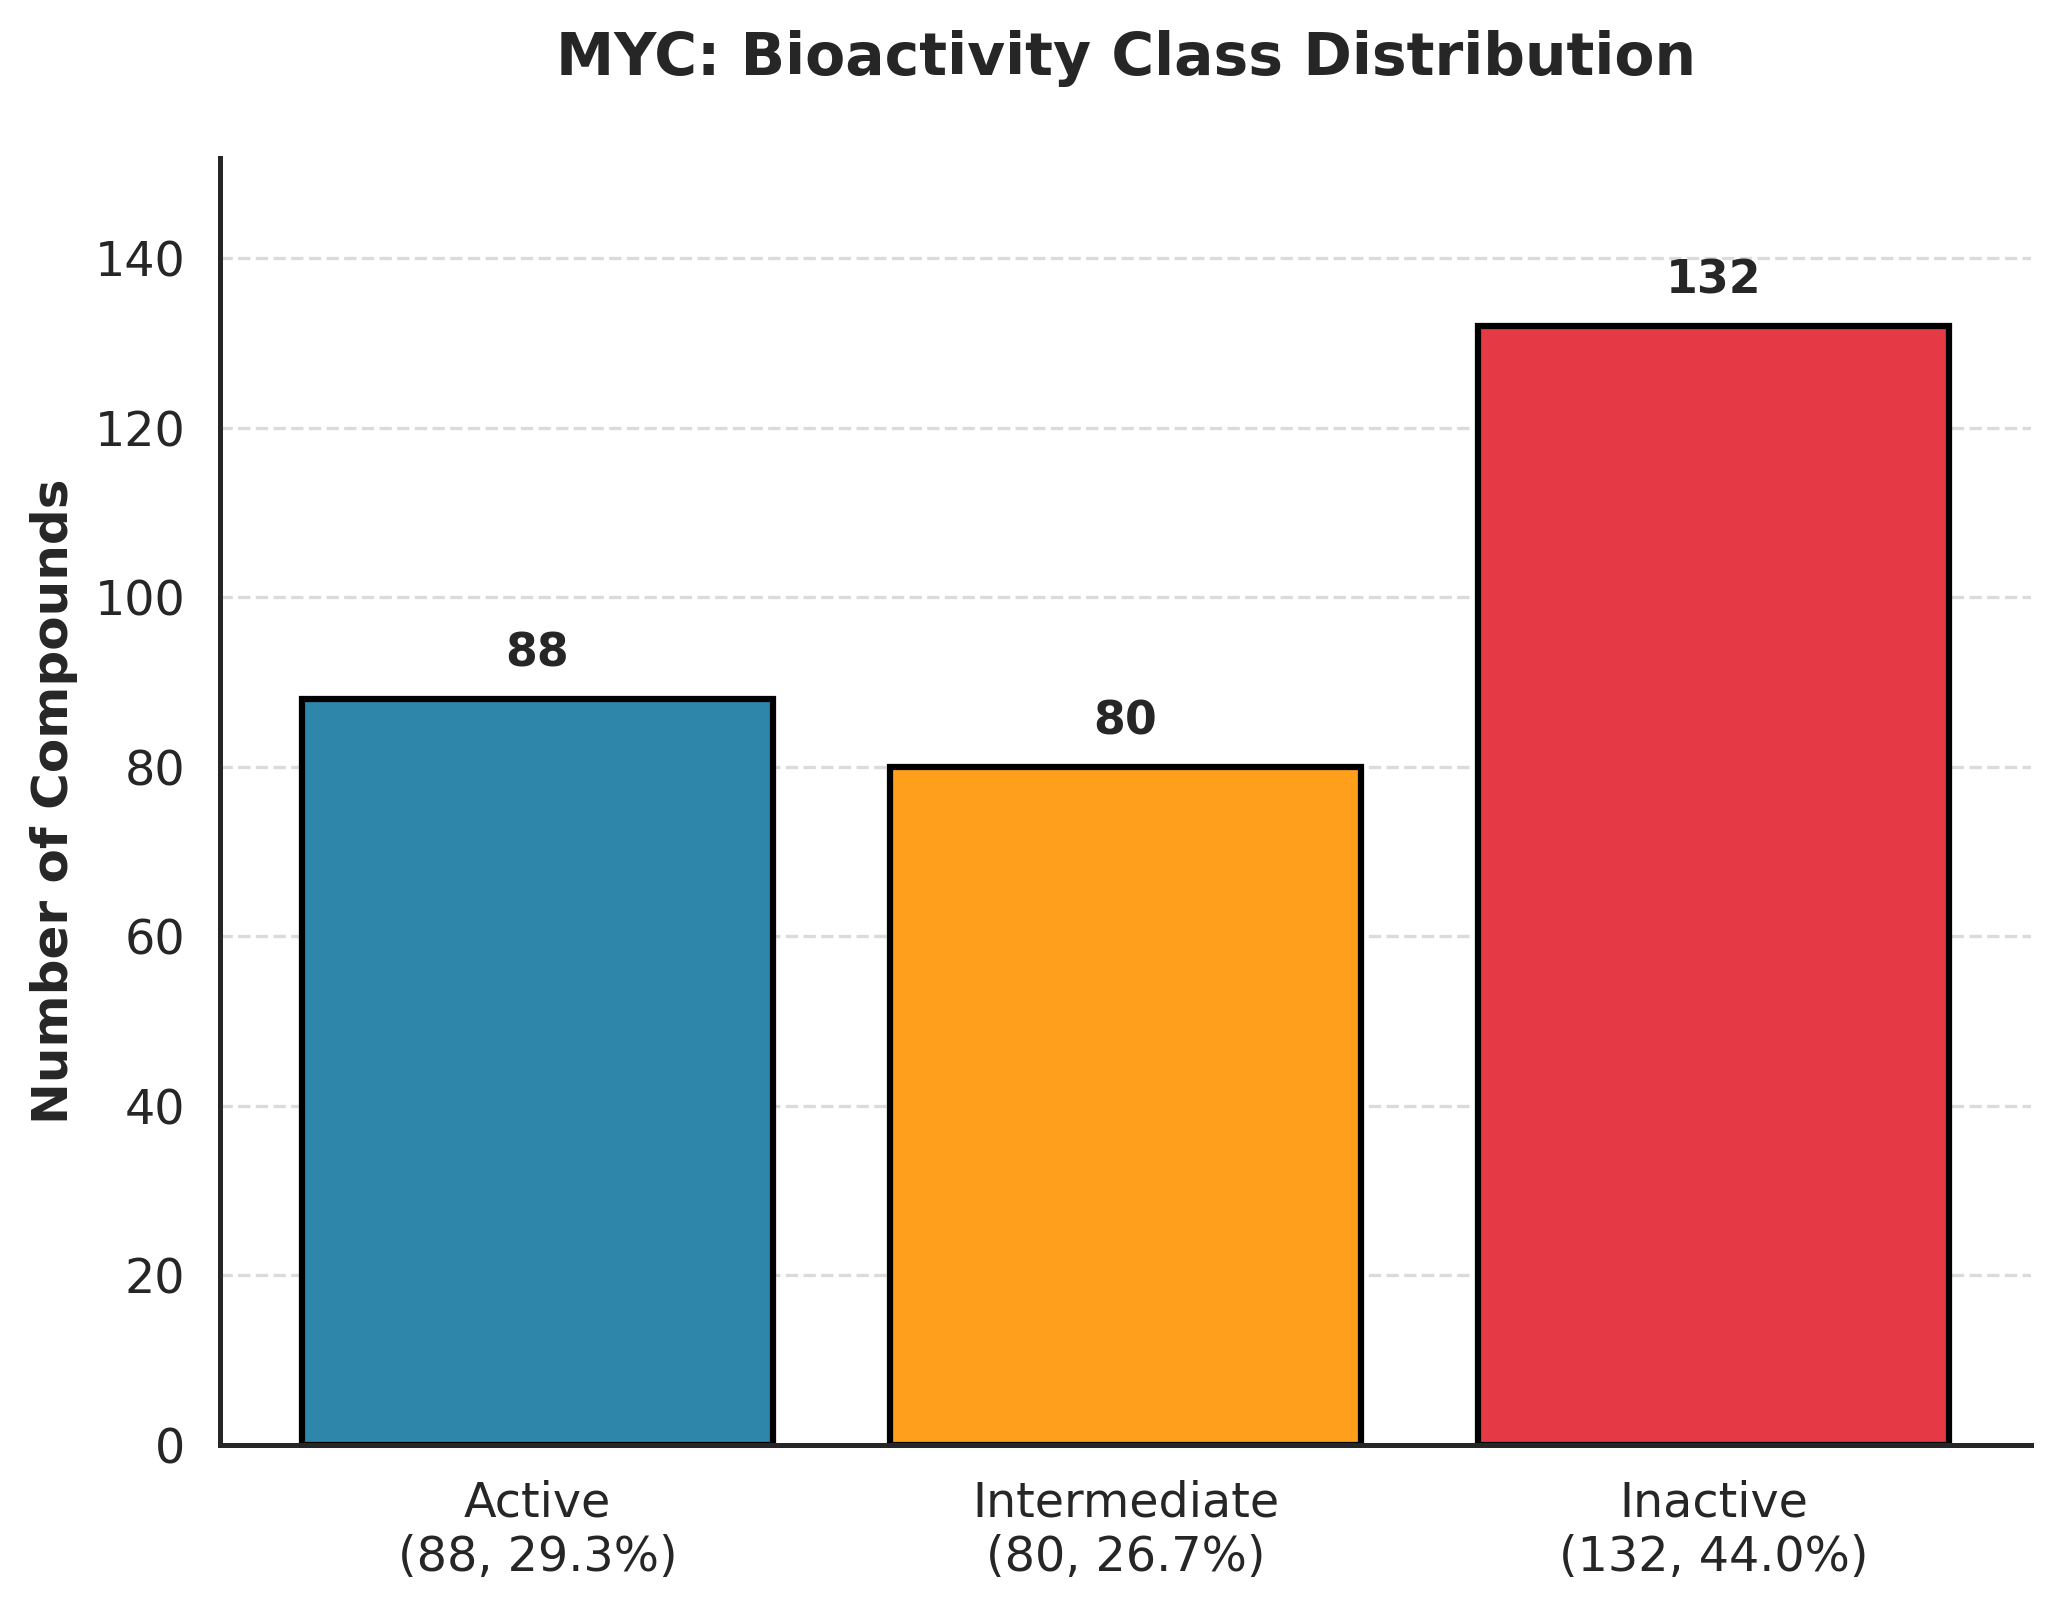

In [12]:
# @title # (A) Class distribution
fig, ax = plt.subplots(figsize=(7, 5.5))
class_order = ["active", "intermediate", "inactive"]
colors = ["#2E86AB", "#FF9F1C", "#E63946"]

counts = []
labels = []
colors_used = []
for c, color in zip(class_order, colors):
    n = int((df_final["class"] == c).sum())
    if n > 0:
        pct = (n / len(df_final)) * 100
        counts.append(n)
        labels.append(f"{c.capitalize()}\n({n}, {pct:.1f}%)")
        colors_used.append(color)

bars = ax.bar(labels, counts, color=colors_used, edgecolor="black", linewidth=1.5)
for bar in bars:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.02*max(counts), f"{int(h)}",
            ha="center", va="bottom", fontweight="bold")

ax.set_ylabel("Number of Compounds", fontweight="bold")
ax.set_title(f"{OUTPUT_PREFIX}: Bioactivity Class Distribution", fontweight="bold", pad=20)
ax.set_ylim(0, max(counts) * 1.15)
ax.yaxis.grid(True, linestyle="--", alpha=0.7)
ax.set_axisbelow(True)
sns.despine()
save_tiff(fig, f"{OUTPUT_PREFIX}_class_distribution_with_percentages")
plt.show()

✅ Saved: PART2_OUTPUTS/MYC_MW_vs_LogP_chemical_space.tiff


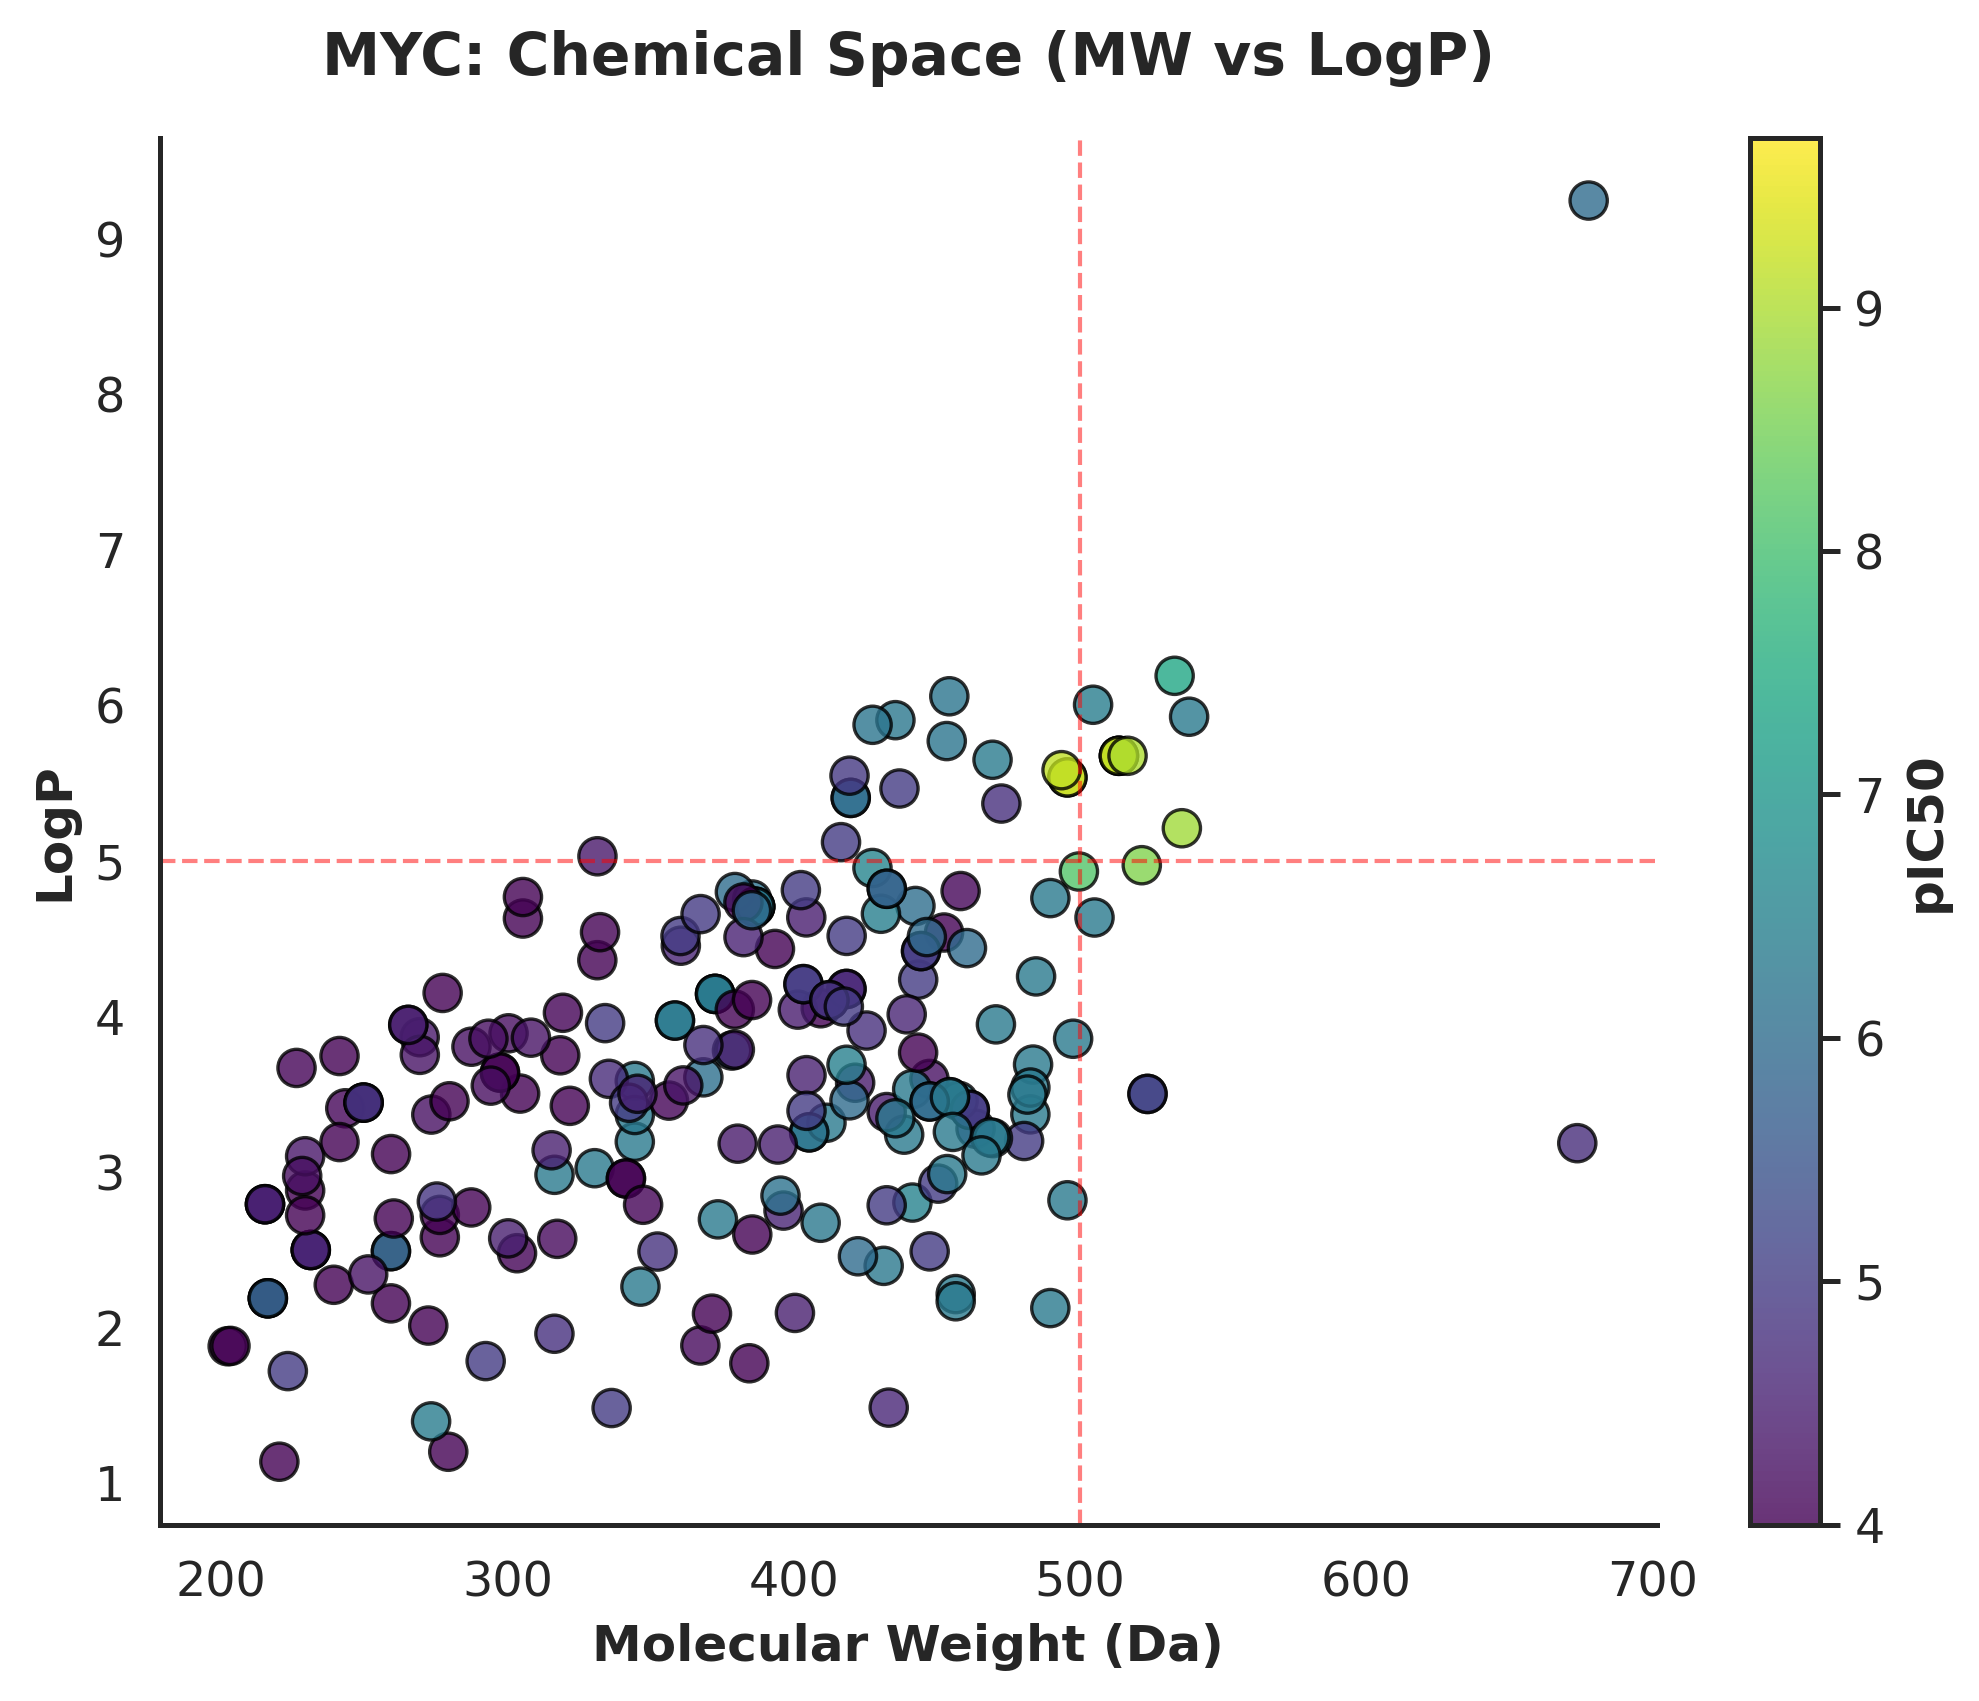

In [13]:
# @title # (B) MW vs LogP scatter ✅ fixed
plot_df = df_2class.replace([np.inf, -np.inf], np.nan).dropna(subset=["MW", "LogP", "pIC50"])
fig, ax = plt.subplots(figsize=(7, 5.8))

sc = ax.scatter(plot_df["MW"], plot_df["LogP"], c=plot_df["pIC50"],
                cmap="viridis", edgecolor="black", alpha=0.8, s=80)

ax.set_title(f"{OUTPUT_PREFIX}: Chemical Space (MW vs LogP)", fontweight="bold", pad=15)
ax.set_xlabel("Molecular Weight (Da)", fontweight="bold")
ax.set_ylabel("LogP", fontweight="bold")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("pIC50", fontweight="bold")

ax.axhline(y=5, color="red", linestyle="--", alpha=0.5, linewidth=1)
ax.axvline(x=500, color="red", linestyle="--", alpha=0.5, linewidth=1)

sns.despine()
save_tiff(fig, f"{OUTPUT_PREFIX}_MW_vs_LogP_chemical_space")
plt.show()

/tmp/ipykernel_5002/3908113386.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(box_data, labels=["Inactive", "Active"],


✅ Saved: PART2_OUTPUTS/MYC_pIC50_boxplot.tiff


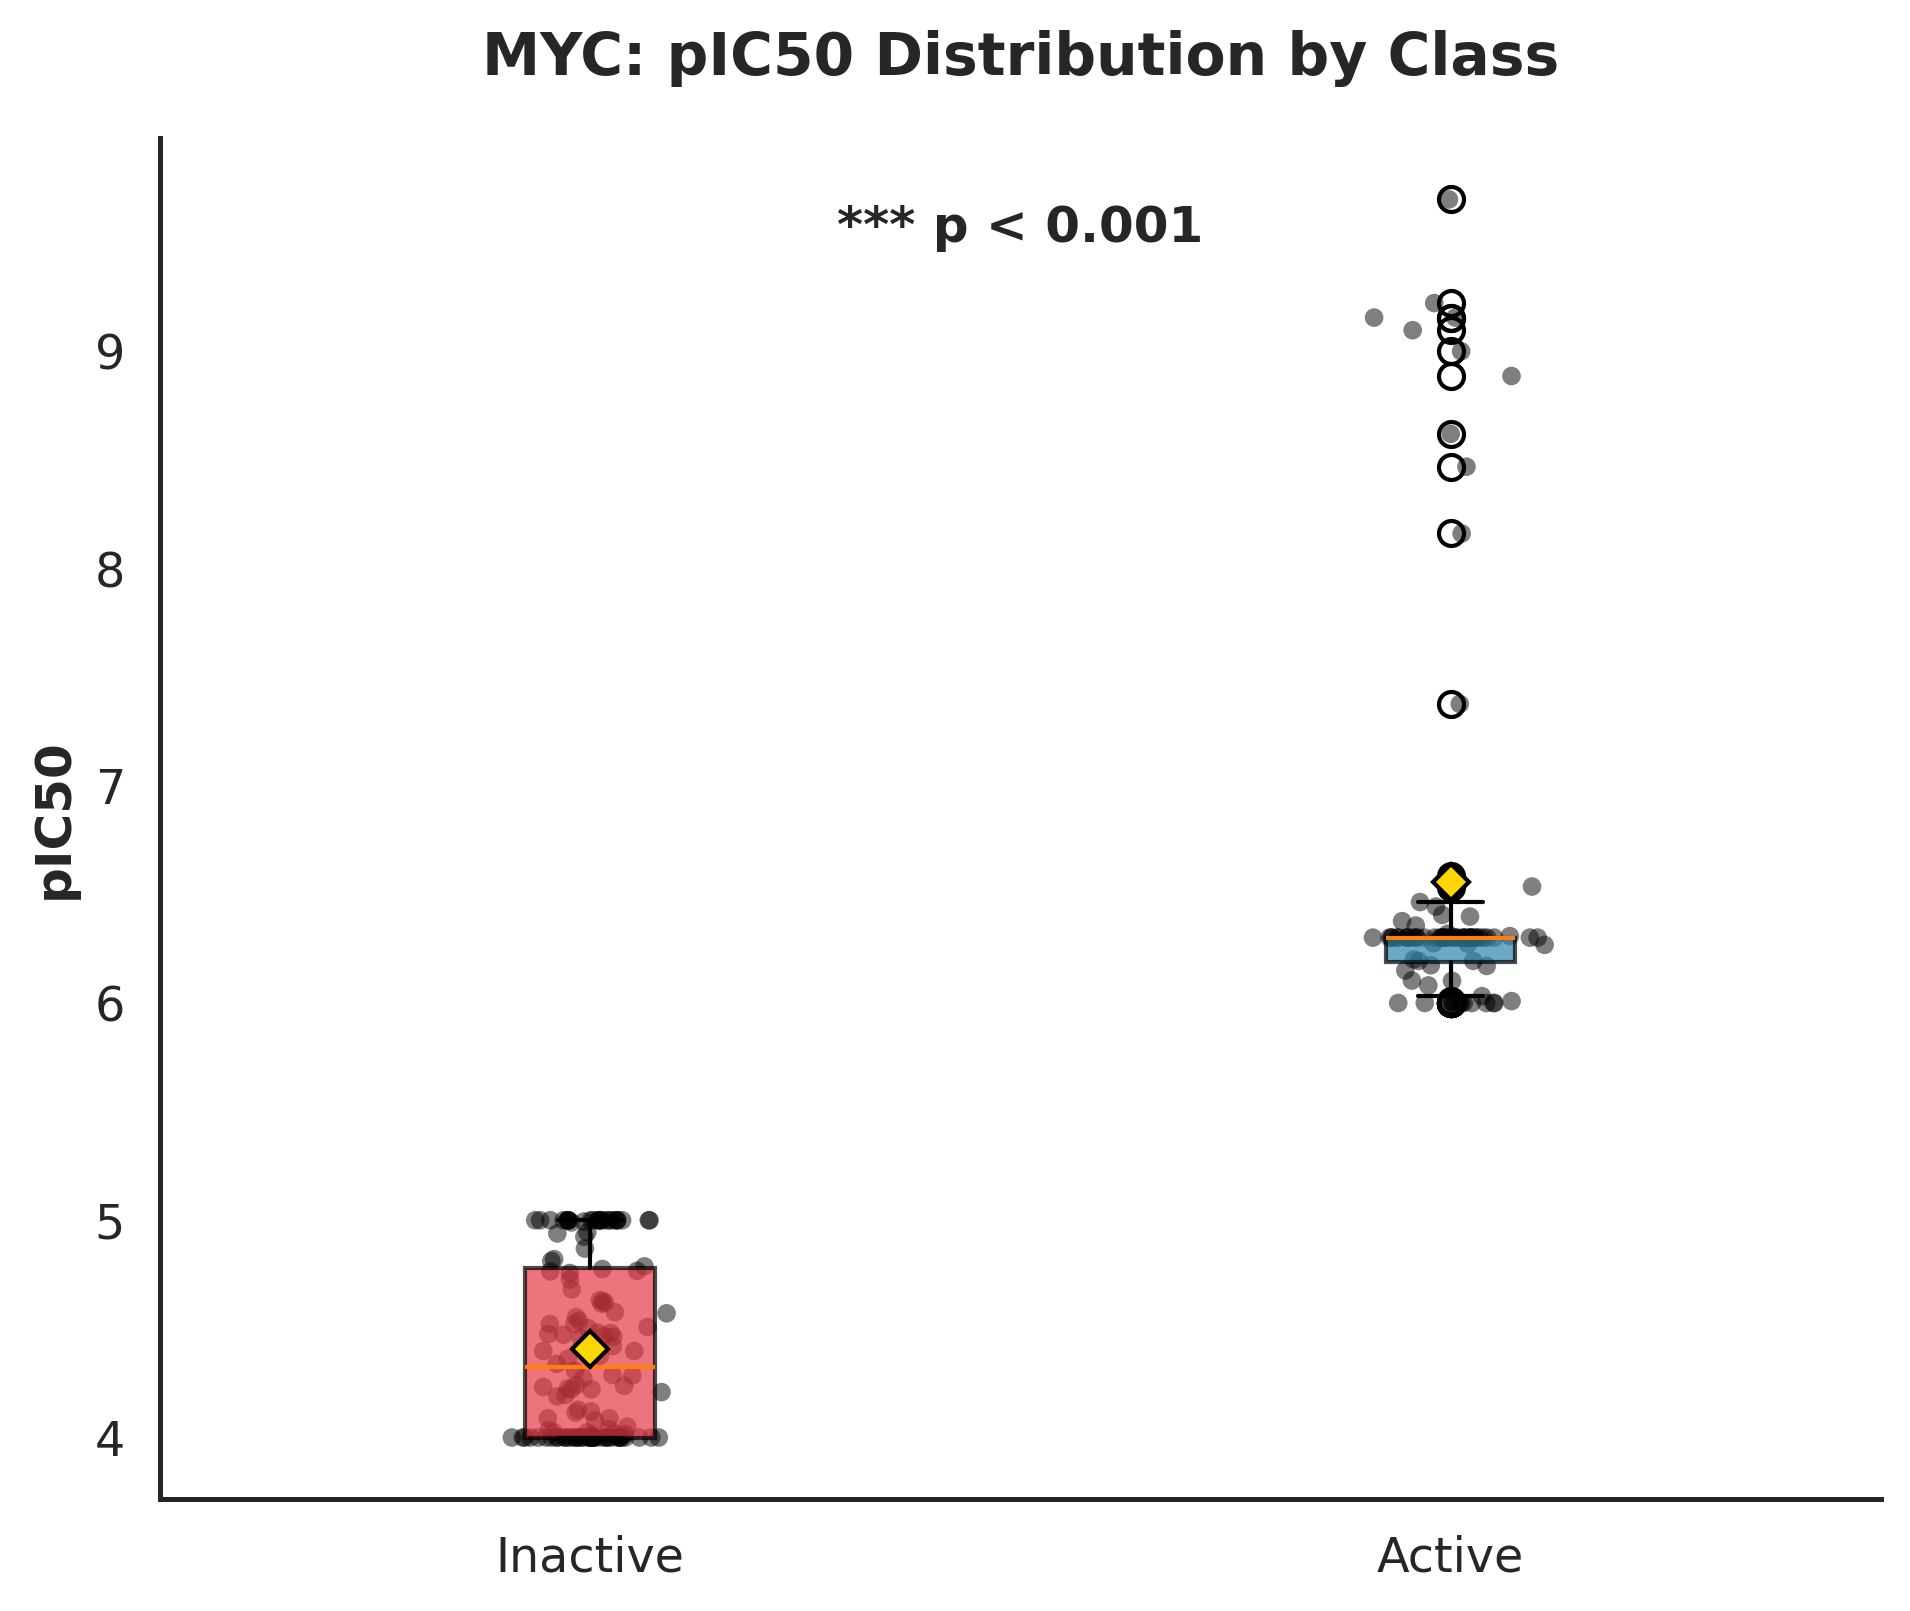

In [14]:
# @title # (C) pIC50 boxplot ✅ Mann–Whitney significance
fig, ax = plt.subplots(figsize=(6.5, 5.5))
inactive = df_2class[df_2class["class"] == "inactive"]["pIC50"].dropna()
active   = df_2class[df_2class["class"] == "active"]["pIC50"].dropna()
box_data = [inactive, active]

box = ax.boxplot(box_data, labels=["Inactive", "Active"],
                 patch_artist=True, showmeans=True,
                 meanprops=dict(marker="D", markeredgecolor="black", markerfacecolor="gold"))

for patch, color in zip(box["boxes"], ["#E63946", "#2E86AB"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

for i, data in enumerate(box_data):
    x = np.random.normal(i + 1, 0.04, size=len(data))
    ax.scatter(x, data, alpha=0.5, s=20, color="black", edgecolor="none")

ax.set_title(f"{OUTPUT_PREFIX}: pIC50 Distribution by Class", fontweight="bold", pad=15)
ax.set_ylabel("pIC50", fontweight="bold")

if len(inactive) >= 5 and len(active) >= 5:
    U, p_val = mannwhitneyu(inactive, active, alternative="two-sided")
    if p_val < 0.001:
        sig_text = "*** p < 0.001"
    elif p_val < 0.01:
        sig_text = "** p < 0.01"
    elif p_val < 0.05:
        sig_text = "* p < 0.05"
    else:
        sig_text = "ns"
    ymax = max(inactive.max(), active.max())
    ax.text(1.5, ymax * 0.98, sig_text, ha="center", fontweight="bold", fontsize=12)

sns.despine()
save_tiff(fig, f"{OUTPUT_PREFIX}_pIC50_boxplot")
plt.show()

✅ Saved: PART2_OUTPUTS/MYC_lipinski_descriptors.tiff


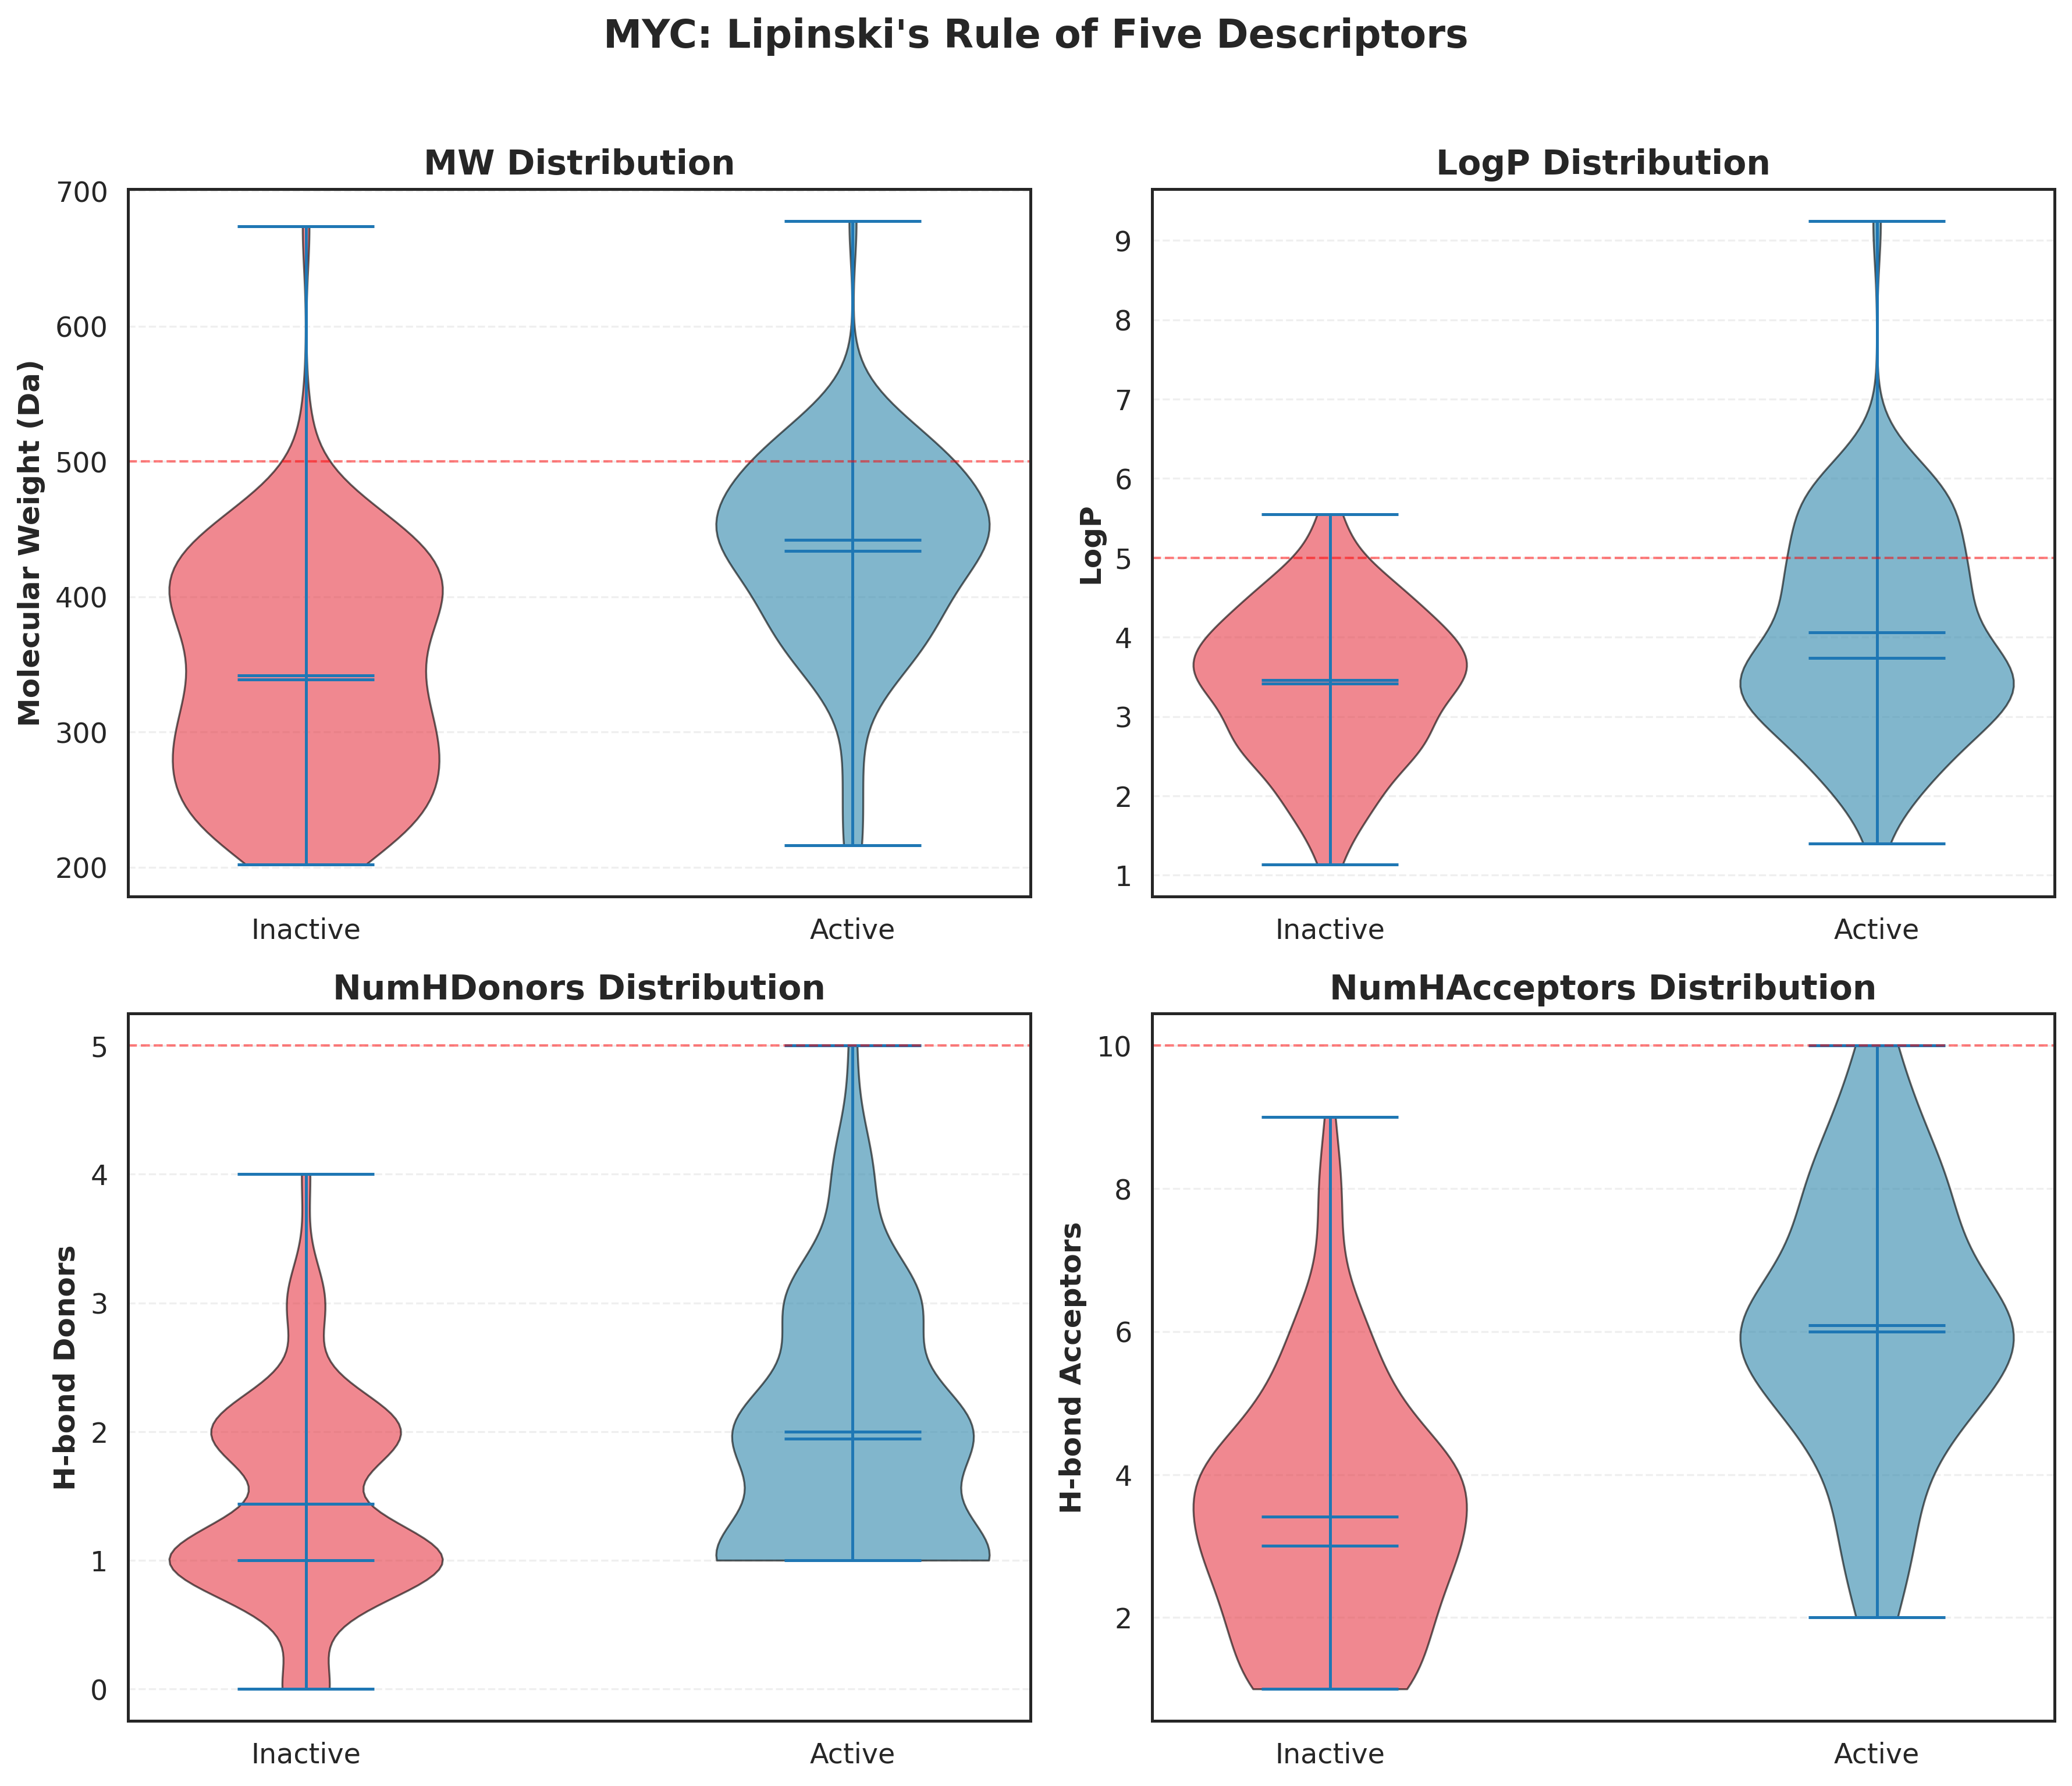

In [15]:
# @title # (D) Lipinski violins
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

lip_cols = ["MW", "LogP", "NumHDonors", "NumHAcceptors"]
lip_limits = [500, 5, 5, 10]
lip_names = ["Molecular Weight (Da)", "LogP", "H-bond Donors", "H-bond Acceptors"]

for idx, (col, limit, name) in enumerate(zip(lip_cols, lip_limits, lip_names)):
    ax = axes[idx]
    violin = ax.violinplot(
        [df_2class[df_2class["class"] == "inactive"][col].dropna(),
         df_2class[df_2class["class"] == "active"][col].dropna()],
        showmeans=True, showmedians=True
    )

    for pc, color in zip(violin["bodies"], ["#E63946", "#2E86AB"]):
        pc.set_facecolor(color)
        pc.set_alpha(0.6)
        pc.set_edgecolor("black")

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Inactive", "Active"])
    ax.set_ylabel(name, fontweight="bold")
    ax.set_title(f"{col} Distribution", fontweight="bold")
    ax.yaxis.grid(True, linestyle="--", alpha=0.3)

    if limit is not None:
        ax.axhline(y=limit, color="red", linestyle="--", alpha=0.5, linewidth=1)

fig.suptitle(f"{OUTPUT_PREFIX}: Lipinski's Rule of Five Descriptors",
             fontweight="bold", fontsize=16, y=1.02)
plt.tight_layout()
save_tiff(fig, f"{OUTPUT_PREFIX}_lipinski_descriptors")
plt.show()

In [16]:
# @title # 13) Mann–Whitney tests + effect size (rank-biserial)
# ==========================================================
print("\n🔬 Mann–Whitney U tests (active vs inactive) ...")
mw_results = []
for col in ["pIC50", "MW", "LogP", "NumHDonors", "NumHAcceptors"]:
    mw_results.append(mann_whitney_test(df_2class, col, class_col="class"))

mw_df = pd.concat(mw_results, ignore_index=True)
mw_path = os.path.join("PART2_OUTPUTS", f"{OUTPUT_PREFIX}_mannwhitney_results.csv")
mw_df.to_csv(mw_path, index=False)
print(f"✅ Saved: {mw_path}")
display(mw_df)


🔬 Mann–Whitney U tests (active vs inactive) ...
✅ Saved: PART2_OUTPUTS/MYC_mannwhitney_results.csv


,Descriptor,U_statistic,p_value,alpha,Interpretation,n_active,n_inactive,Effect_size_rank_biserial
0,pIC50,11616.0,1.3331e-36,0.05,Significantly different (p ≤ 0.05),88,132,-1.000
1,MW,9371.5,1.3242e-14,0.05,Significantly different (p ≤ 0.05),88,132,-0.614
2,LogP,7399.0,5.8434e-04,0.05,Significantly different (p ≤ 0.05),88,132,-0.274
3,NumHDonors,7398.0,2.1926e-04,0.05,Significantly different (p ≤ 0.05),88,132,-0.274
4,NumHAcceptors,9899.0,4.4284e-19,0.05,Significantly different (p ≤ 0.05),88,132,-0.704


In [17]:
# @title Summary (Just rub)
import os

# Ensure the output directory exists
os.makedirs("PART2_OUTPUTS", exist_ok=True)

# Define the path for the combined text report
report_filename = f"{OUTPUT_PREFIX}_summary_report.txt"
report_path = os.path.join("PART2_OUTPUTS", report_filename)

print(f"\n📝 Compiling summary reports into: {report_path}")

with open(report_path, "w") as f:
    f.write(f"--- Combined Summary Report for {OUTPUT_PREFIX} ---\n\n")

    # Write Final Curation Flow
    f.write("### 📈 Final Curation Flow ###\n")
    # The 'flow' variable was updated throughout the notebook, so we'll use the latest one
    final_flow_df = pd.DataFrame(flow, columns=["Step", "Count"])
    f.write(final_flow_df.to_string(index=False))
    f.write("\n\n")

    # Write Class Statistics
    f.write("### Class Statistics ###\n")
    f.write(class_stats.to_string(index=False))
    f.write("\n\n")

    # Write Mann-Whitney Test Results
    f.write("### 🔬 Mann–Whitney U tests (active vs inactive) ###\n")
    f.write(mw_df.to_string(index=False))
    f.write("\n\n")

    f.write(f"--- End of Report for {OUTPUT_PREFIX} ---\n")

print(f"✅ All summary reports saved to: {report_path}")


📝 Compiling summary reports into: PART2_OUTPUTS/MYC_summary_report.txt
✅ All summary reports saved to: PART2_OUTPUTS/MYC_summary_report.txt


In [18]:
# @title # 14) Zip + download outputs
# ==========================================================
import zipfile
from google.colab import files

zip_name = os.path.join("PART2_OUTPUTS", f"{OUTPUT_PREFIX}_Part2_outputs.zip")
files_to_zip = [fn for fn in os.listdir("PART2_OUTPUTS") if fn.startswith(OUTPUT_PREFIX)]

if files_to_zip:
    with zipfile.ZipFile(zip_name, "w", compression=zipfile.ZIP_DEFLATED) as z:
        for fn in files_to_zip:
            z.write(os.path.join("PART2_OUTPUTS", fn), arcname=fn)

    print(f"\n✅ Created: {zip_name}")
    files.download(zip_name)
else:
    print("⚠️ No output files found to zip.")

print("\n🎉 Part-2 completed. Next: Part-3.1 (descriptor generation)")



✅ Created: PART2_OUTPUTS/MYC_Part2_outputs.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 Part-2 completed. Next: Part-3.1 (descriptor generation)
